In [3]:
import pandas as pd

In [4]:
df_dichte = pd.read_csv("../../data/processed/bevoelkerungsdichte_2024.csv")
df_typen = pd.read_csv("typen.csv")

df = df_dichte.merge(df_typen, how="left", on="Name")

print(df)

                          Name  Bevölkerungsdichte             Typ 1  \
0                   Düsseldorf              2845.7  Kreisfreie Stadt   
1                     Duisburg              2157.1  Kreisfreie Stadt   
2                        Essen              2732.2  Kreisfreie Stadt   
3                      Krefeld              1679.5  Kreisfreie Stadt   
4              Mönchengladbach              1567.5  Kreisfreie Stadt   
5          Mülheim an der Ruhr              1895.8  Kreisfreie Stadt   
6                   Oberhausen              2771.4  Kreisfreie Stadt   
7                    Remscheid              1527.5  Kreisfreie Stadt   
8                     Solingen              1849.7  Kreisfreie Stadt   
9                    Wuppertal              2127.2  Kreisfreie Stadt   
10                       Kleve               261.2     Kleiner Kreis   
11                    Mettmann              1205.5      Großer Kreis   
12           Rhein-Kreis Neuss               792.9      Großer K

In [5]:
df.groupby("Typ 1")["Bevölkerungsdichte"].describe()

,count,mean,std,min,25%,50%,75%,max
Typ 1,,,,,,,,
Großer Kreis,22.0,485.440909,265.952251,133.1,270.55,411.85,671.225,1205.5
Kleiner Kreis,8.0,232.825000,94.160240,115.9,180.00,209.55,270.475,419.9
Kreisfreie Stadt,22.0,1989.390909,643.461105,794.8,1537.50,2132.35,2512.950,3030.9
Städteregion,1.0,823.900000,NaN,823.9,823.90,823.90,823.900,823.9


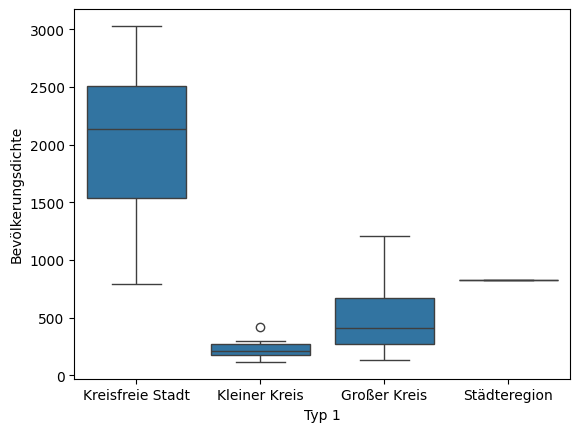

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="Typ 1", y="Bevölkerungsdichte")
plt.show()

In [7]:
# Kruskal (nicht-parametrisch, da nicht normalverteilt)
from scipy.stats import kruskal

groups = [
    df.loc[df["Typ 1"] == t, "Bevölkerungsdichte"]
    for t in df["Typ 1"].unique()
]

median_diff_test = kruskal(*groups)

print(median_diff_test)

KruskalResult(statistic=np.float64(40.14174766533256), pvalue=np.float64(9.942816499507016e-09))


In [8]:
# einfaktorielle Anova
H = median_diff_test[0]
k = df["Typ 1"].nunique()
n = len(df)


eta_squared = (H - k + 1) / (n - k)
print(eta_squared)

0.7579948503129094


In [9]:
aachen = df.loc[df["Name"] == "Aachen", "Bevölkerungsdichte"].iloc[0]
summary = df.groupby("Typ 1")["Bevölkerungsdichte"].median()

dist_to_city = abs(aachen - summary["Kreisfreie Stadt"])
dist_to_large = abs(aachen - summary["Großer Kreis"])

print(dist_to_city, dist_to_large)


1308.4499999999998 412.04999999999995
